# Checking `SpectrumPrecompute` Outputs

Note: the precomputed files were generated in python 3.8 and numpy 1.22.

It might not be necessary to also run in python 3.8 and numpy 1.22; more recently I have not been doing this.

There are some difficulties reading the group and dict outputs.

To get the loading of the mask function to work, one must:

* `pip install -e SequenceFunctions` in `cavity_labscriptlib/RbCavity`
* `pip install -e labscript` (in the folder above `labscript_devices`)

In [2]:
import numpy as np
import glob
import os
import io
import matplotlib.pyplot as plt
import pickle
# import tqdm

## Structure of the Precomputed Files

TODO: flesh out this explanation

* `*SpectrumM4X.npy`: contains the waveforms
* `*SpectrumM4X_groups.npy`: contains the group information
* `*SpectrumM4X_dict.npy`: contains the dictionary information

In [3]:
precomputed_spectrum_folder = "SpectrumPrecomputeCopied"

waveforms_file_pattern = os.path.join(precomputed_spectrum_folder, "*SpectrumM4X.npy")
dict_file_pattern = os.path.join(precomputed_spectrum_folder, "*SpectrumM4X_dict.npy")
groups_file_pattern = os.path.join(precomputed_spectrum_folder, "*SpectrumM4X_groups.npy")

waveform_files = glob.glob(waveforms_file_pattern)
dict_files = glob.glob(dict_file_pattern)
groups_files = glob.glob(groups_file_pattern)

print(len(waveform_files))
print(len(dict_files))
print(len(groups_files))

# I am going to assume that the files are sorted in the same order as long as this holds
assert len(waveform_files) == len(dict_files) == len(groups_files)

file_triplets = list(zip(waveform_files, dict_files, groups_files))


33
33
33


In [4]:
class Extraction:
    def __init__(self, filename, waveform_data, dict_data=None, groups_data=None):
        self.filename = filename
        self.waveform_dict = waveform_data.item()

        if dict_data is not None:
            self.dict_dict = dict_data.item()
        
        if groups_data is not None:
            self.groups_dict = groups_data.item()

extractions = [] 

waveform_datasets = []


for waveform_file, dict_file, groups_file in file_triplets[:5]:
    # group = pickle.load(open(file, "rb"))   
    #
    # the above doesn't for some reason
    # see https://stackoverflow.com/questions/40518780/how-to-np-loads-an-np-saved-array

    print("Attempting to load waveform:")
    with open(waveform_file, 'rb') as f:
        ffff = f.read()
        waveform_data = np.load(io.BytesIO(ffff), allow_pickle=True)
    


    # Throws an error when tyring to use dict_file. Neither option works.
    # 
    dict_data = np.load(dict_file, allow_pickle=True)

    extractions.append(Extraction(waveform_file, waveform_data, dict_data))

    print("Skipping loading groups.")

    #
    # with open(dict_file, 'rb') as f:
    #     ffff = f.read()
    #     dict_data = np.load(io.BytesIO(ffff), allow_pickle=True)

    # dict_data = np.load(io.BytesIO(open(dict_file, 'rb').read()), allow_pickle=True)
    
    ### None of the below work
    # groups_data = np.load(io.BytesIO(open(groups_file, 'rb').read()), allow_pickle=False)
    #
    # group = pickle.load(open(file, "rb"))   
    #
    # with open(groups_file, 'rb') as f:
    #     ffff = f.read().replace(b'\r\n', b'\n') # Reading the data in binary mode and calling .replace
    #     groups_data = pickle.loads(ffff)               # loads

    break

Attempting to load waveform:
Skipping loading groups.


In [5]:
# dict_data.item() # this crashes
print(dict_data.item().keys()) # this works

# print(dict_data.item().values())

dict_keys(['channel_settings', 'device_settings', 'waveform_groups'])


In [6]:
for key, value in dict_data.item().items():
    print(key)
    print(type(value))
    pass

channel_settings
<class 'numpy.ndarray'>
device_settings
<class 'numpy.void'>
waveform_groups
<class 'dict'>


In [7]:
dict_data.item()["device_settings"]

(b'sequence', 5.e+08, 1, 10000000., False, '')

In [8]:
dict_data.item()["channel_settings"]

array([( 0.  , b'microwaves', 0), (17.96, b'tweezers', 1),
       (-7.  , b'probe', 2), ( 0.  , b'raman', 3)],
      dtype=[('power', '<f8'), ('name', 'S10'), ('port', '<i4')])

In [9]:
dict_data.item()["waveform_groups"].keys()

dict_keys(['group 0', 'group 1', 'group 2', 'group 3', 'group 4', 'group 5', 'group 6', 'group 7', 'group 8', 'group 9'])

In [10]:

dict_data.item()["waveform_groups"]["group 0"].keys()

dict_keys(['Waveform: ch = 0, t = 4112000, dur = 2031', 'group_settings'])

In [11]:
dict_data.item()["waveform_groups"]["group 0"]["group_settings"]

(4112000, 2031, 1)

In [12]:
dict_data.item()["waveform_groups"]["group 0"]['Waveform: ch = 0, t = 4112000, dur = 2031'].keys()

dict_keys(['pulse_data', 'waveform_settings'])

In [13]:
for groupkey in dict_data.item()["waveform_groups"]:
    print(dict_data.item()["waveform_groups"][groupkey].keys())

dict_keys(['Waveform: ch = 0, t = 4112000, dur = 2031', 'group_settings'])
dict_keys(['Waveform: ch = 1, t = 4162988, dur = 509', 'Waveform: ch = 3, t = 4163097, dur = 400', 'group_settings'])
dict_keys(['Waveform: ch = 0, t = 4163935, dur = 164321', 'Waveform: ch = 1, t = 4163888, dur = 3484', 'Waveform: ch = 1, t = 4167888, dur = 2229', 'Waveform: ch = 1, t = 4170696, dur = 3484', 'Waveform: ch = 1, t = 4174696, dur = 2229', 'Waveform: ch = 1, t = 4177504, dur = 3484', 'Waveform: ch = 1, t = 4181504, dur = 2229', 'Waveform: ch = 1, t = 4184312, dur = 3484', 'Waveform: ch = 1, t = 4188312, dur = 2229', 'Waveform: ch = 1, t = 4191120, dur = 3484', 'Waveform: ch = 1, t = 4195120, dur = 2229', 'Waveform: ch = 1, t = 4197928, dur = 3484', 'Waveform: ch = 1, t = 4201928, dur = 2229', 'Waveform: ch = 1, t = 4204736, dur = 3484', 'Waveform: ch = 1, t = 4208736, dur = 2229', 'Waveform: ch = 1, t = 4211544, dur = 3484', 'Waveform: ch = 1, t = 4215544, dur = 2229', 'Waveform: ch = 1, t = 421838

In [14]:
# Can't access waveform_settings! It is numpy.void, which is fine, but I can't access it.
waveform_settings = dict_data.item()["waveform_groups"]["group 0"]['Waveform: ch = 0, t = 4112000, dur = 2031']['waveform_settings']
waveform_settings = waveform_settings[0]

In [15]:
print(waveform_settings.dtype)

{'names': ['time', 'duration', 'loops', 'port', 'sample_start', 'sample_end', 'delta_start', 'delta_end', 'modulation_frequencies', 'modulation_amplitudes', 'modulation_phases', 'mask', 'has_mask', 'remove_self_interaction'], 'formats': ['<i4', '<i4', '<i4', '<i4', '<i4', '<i4', '<i4', '<i4', '<f8', '<f8', '<f8', 'O', '?', '?'], 'offsets': [0, 4, 8, 12, 16, 20, 24, 28, 32, 40, 48, 56, 60, 61], 'itemsize': 62}


In [ ]:
for m, groupkey in enumerate(dict_data.item()["waveform_groups"]):
    print(groupkey)
    for k, key in enumerate(dict_data.item()["waveform_groups"][groupkey]):
        key: str
        print()
        print(key)
        print("---------------------")
    
        if key.startswith("Waveform:"):
            waveform_settings = dict_data.item()["waveform_groups"][groupkey][key]['waveform_settings'][0]

            for n, name in enumerate(waveform_settings.dtype.names):
                if n == 11:
                    if waveform_settings[12]:
                        print("Mask detected, printing length")

                        # See lines 2210 to 2213 in Spectrum.py for how this was originally done.
                        # we essentially do the same thing here
                        mask_str = waveform_settings[11][0]
                        # mask_pickle = bytes(eval(mask_str))
                        # mask = pickle.loads(mask_pickle)
                        # print(len(waveform_settings[11]))
                    else:
                        print("Skipping mask")
                    continue


: 

In [ ]:
pulsedata = dict_data.item()["waveform_groups"]["group 0"]['Waveform: ch = 0, t = 4112000, dur = 2031']['pulse_data']

for p in pulsedata[0]:
    print(p)

: 

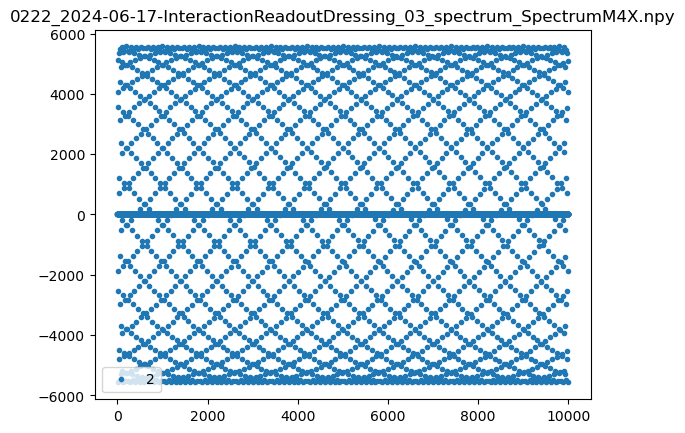

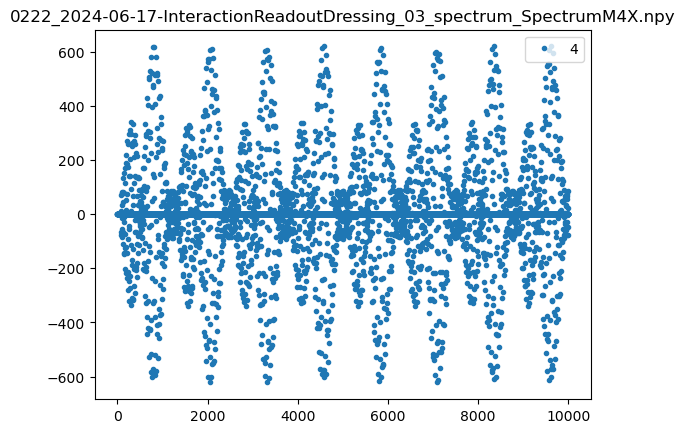

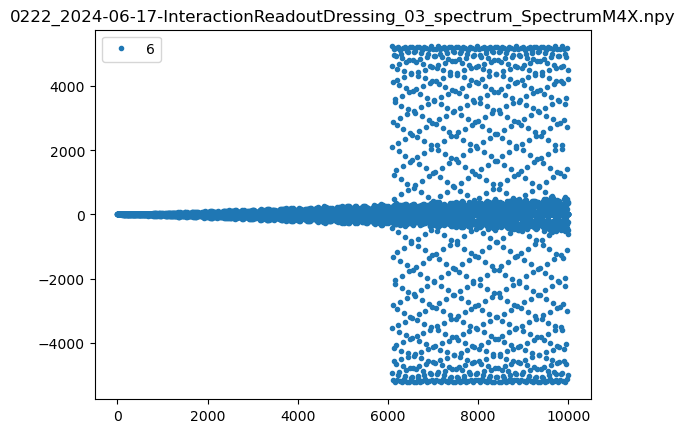

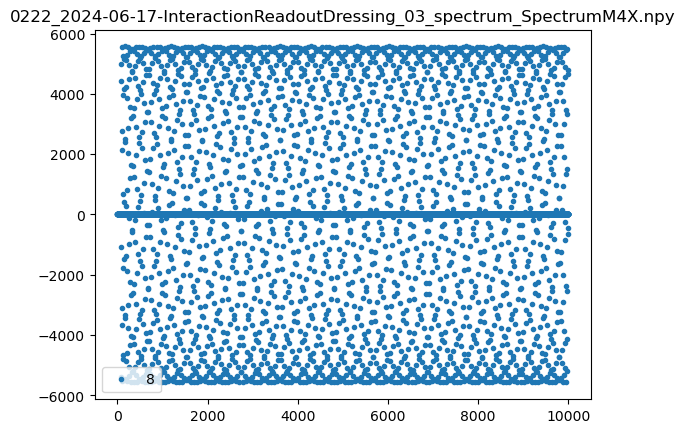

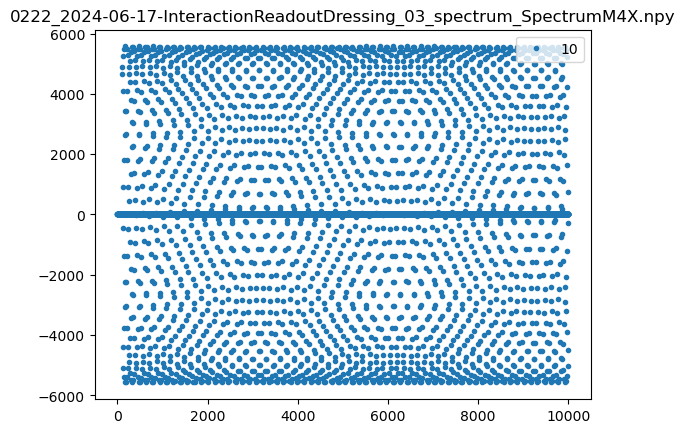

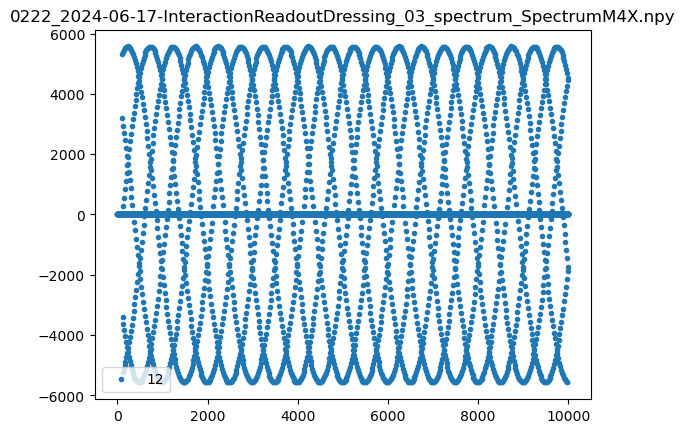

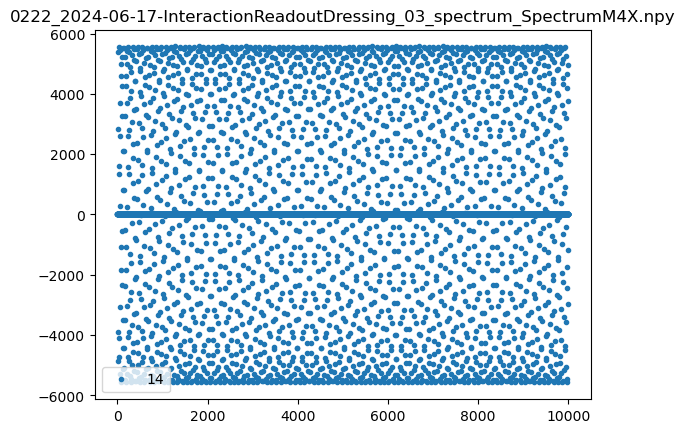

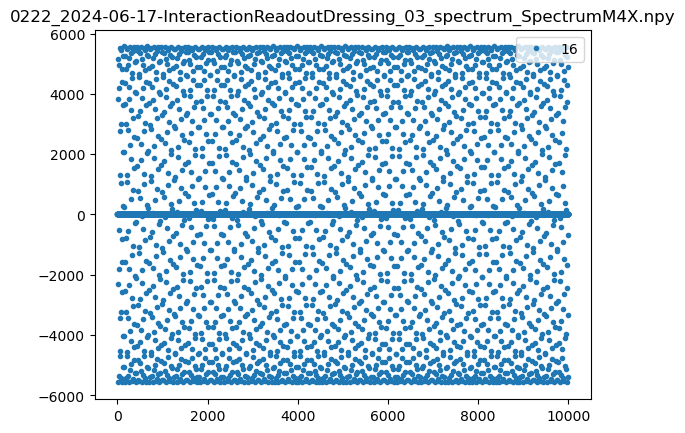

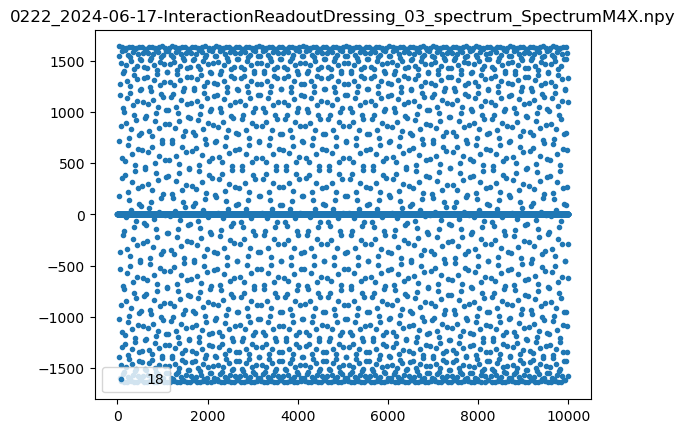

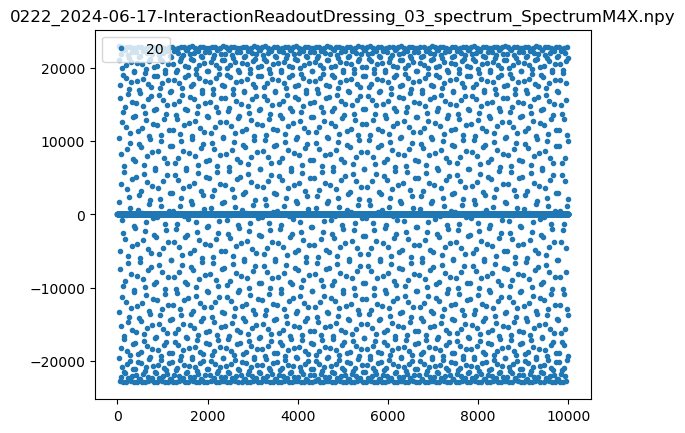

In [13]:
%matplotlib inline

for e in extractions[::-1][:2]:
    for key, arr in e.waveform_dict.items():
        plt.figure()
        plt.plot(arr[:10000], ".", label=key)
        plt.legend()
        plt.title(e.filename.split("/")[-1])

